# K-Nearest Neighbors From Scratch

Implemented using **NumPy** — `sklearn` is only used to load the Breast Cancer dataset.

In this notebook we implement **K-Nearest Neighbors (KNN) from scratch**, covering:
- What KNN is and how it works
- **Euclidean Distance** — measuring closeness between points
- **Majority Vote** — turning neighbors into a prediction
- A clean, reusable `KNN` class with `fit` and `predict`
- Our own **`train_test_split`** — no sklearn utilities

Resources that helped me build this:

Video 1 — Intuition & Implementation: https://youtu.be/ngLyX54e1LU?si=q4JkuSR5KxTkMRCl

video 2 - https://youtu.be/HVXime0nQeI?si=3elgYjFcnVMSqcna

## What is K-Nearest Neighbors?

**K-Nearest Neighbors** is one of the simplest and most intuitive classification algorithms.

The idea: to classify a new point, look at the **K closest training examples** (its "neighbors") and take a **majority vote** among their labels.

There is **no training phase** — KNN is a *lazy learner*. It memorizes the entire dataset and does all the work at prediction time.

### How it works step by step:
1. Compute the distance from the new point to every training point
2. Sort by distance and pick the K smallest
3. Return the most common class label among those K neighbors

### The key parameter: K
- **Small K** → complex boundary, sensitive to noise (overfitting)
- **Large K** → smoother boundary, more robust (can underfit)
- K is typically chosen to be **odd** to avoid ties

Unlike Decision Trees, KNN draws **smooth, curved** boundaries shaped directly by the data.

Let's start coding 🤓.

## 1.Imports

In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer  # only used to load the dataset

## 2. Load & Explore Data

We use the **Breast Cancer Wisconsin** dataset — 569 samples, 30 features, 2 classes:
- **Benign (B)** — non-cancerous
- **Malignant (M)** — cancerous

We load it straight from sklearn (no CSV file needed) and keep everything as NumPy arrays.

In [2]:
bc = load_breast_cancer()

X = bc.data                                        # shape (569, 30)
y = np.where(bc.target == 1, "B", "M")             # 1 → Benign, 0 → Malignant

FEATURE_NAMES = bc.feature_names

print(f"Dataset shape : {X.shape}")
print(f"Classes       : {np.unique(y)}")
print(f"Class counts  : B={np.sum(y == 'B')}, M={np.sum(y == 'M')}")
print(f"\nFirst 2 feature names: {FEATURE_NAMES[:2]}")

Dataset shape : (569, 30)
Classes       : ['B' 'M']
Class counts  : B=357, M=212

First 2 feature names: ['mean radius' 'mean texture']


## 3. Visualize the Data

Before training, let's look at the data through the lens of its two most informative features:
**radius mean** and **texture mean**.

Even in just 2 dimensions we can already see meaningful separation between the two classes.

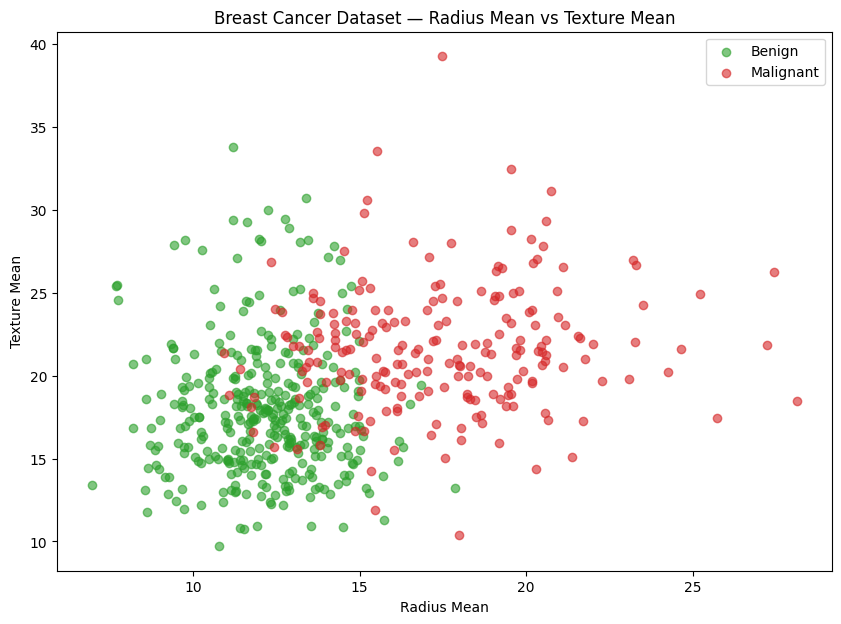

In [3]:
plt.figure(figsize=(10, 7))
plt.scatter(X[y == "B", 0], X[y == "B", 1], color="tab:green", alpha=0.6, label="Benign")
plt.scatter(X[y == "M", 0], X[y == "M", 1], color="tab:red",   alpha=0.6, label="Malignant")
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title("Breast Cancer Dataset — Radius Mean vs Texture Mean")
plt.legend()
plt.show()

## 4. Train / Test Split — From Scratch

Same implementation as in our other notebooks: shuffle indices with NumPy's random permutation, then slice.

In [4]:
def train_test_split(X, y, test_size=0.2, random_state=None):
    """
    Randomly split X and y into train and test sets.

    test_size    : fraction of data used for testing (default 0.2)
    random_state : seed for reproducibility
    """
    if random_state is not None:
        np.random.seed(random_state)

    m = len(y)
    indices = np.random.permutation(m)

    split = int(m * (1 - test_size))
    train_idx, test_idx = indices[:split], indices[split:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

print(f"Train size : {len(y_train)}")
print(f"Test  size : {len(y_test)}")

Train size : 455
Test  size : 114


## 5. Euclidean Distance

The standard way to measure closeness between two points in $n$ dimensions:

$$d(a, b) = \sqrt{\sum_{i=1}^{n} (a_i - b_i)^2} = \lVert a - b \rVert_2$$

This is just the length of the difference vector — the straight-line distance you learned in geometry, extended to any number of dimensions.

We compute this for **all training points at once** using `np.linalg.norm` — fully vectorized, no Python loop.

## 6. The KNN Class

**`fit`** — just stores the training data. KNN has no actual training step.

**`predict`** — for each test point:
1. Computes the Euclidean distance to **all** training points in one vectorized call
2. Sorts by distance and picks the K nearest indices
3. Looks up the labels for those K indices
4. Returns the majority class label via `Counter.most_common`

Everything is vectorized — no Python loop inside `predict_single`.

In [5]:
class KNN:
  def __init__(self, k=5):
    self.k = k

  def fit(self, X, y):
    """
    store the training data.
    !Knn has no actual train step
    """
    self.X_train = X
    self.y_train = y
    return self

  def predict(self, X):
    """
    for each test point:
    1. compute the Euclidean distance to all training points in one vectorized call
    2. sort by distance and pick the K nearest indices
    3. look up the labels for those K indices
    4. return the majority class label via Counter.most_common
    """
    y_pred = [self._predict_single(x) for x in X]
    return np.array(y_pred)

  def _predict_single(self, x):
    """
    predict a single test point
    """
    #distance from x to every training point
    distances = np.linalg.norm(self.X_train - x, axis=1)
    # indices of the K nearest neighbors
    idx = np.argsort(distances)[:self.k]
    # labels of the K nearest neighbors
    labels = self.y_train[idx]
    return Counter(labels).most_common(1)[0][0]


## 7. Train & Evaluate

We try a few values of K and track test accuracy to see how the choice of K matters.

In [6]:
results = {}

for k in [1, 3, 5, 7, 9, 11]:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    predictions = knn.predict(X_test)
    acc = np.mean(predictions == y_test) * 100
    results[k] = acc
    print(f"K={k:2d} | Accuracy: {acc:.2f}%")

best_k = max(results, key=results.get)
print(f"\nBest K = {best_k} with accuracy {results[best_k]:.2f}%")

K= 1 | Accuracy: 92.98%
K= 3 | Accuracy: 95.61%
K= 5 | Accuracy: 96.49%
K= 7 | Accuracy: 96.49%
K= 9 | Accuracy: 95.61%
K=11 | Accuracy: 95.61%

Best K = 5 with accuracy 96.49%


## 8. Visualize K vs Accuracy

A quick plot showing how accuracy changes as we vary K.
This is a simple way to pick the best K without a validation set.

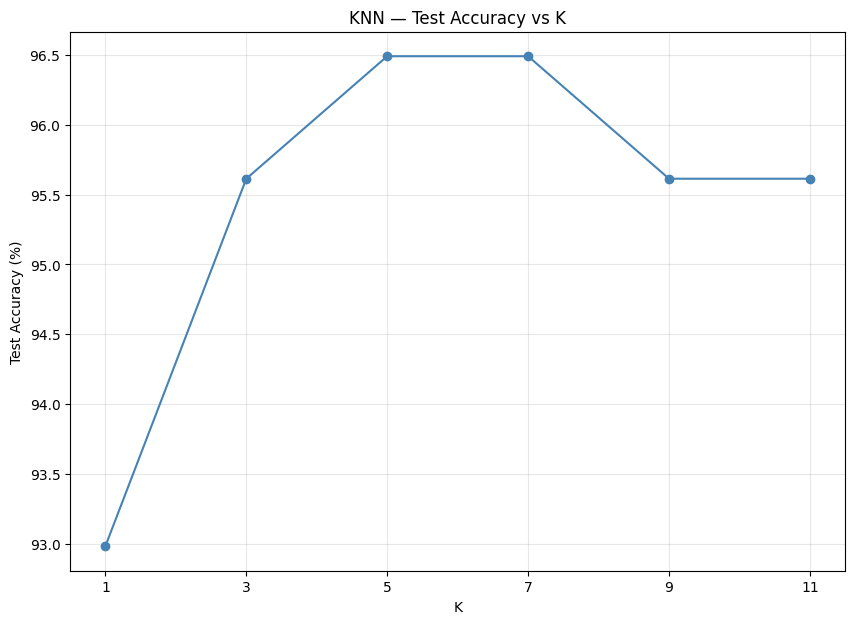

In [7]:
plt.figure(figsize=(10, 7))
plt.plot(list(results.keys()), list(results.values()), marker="o", color="steelblue")
plt.xlabel("K")
plt.ylabel("Test Accuracy (%)")
plt.title("KNN — Test Accuracy vs K")
plt.xticks(list(results.keys()))
plt.grid(True, alpha=0.3)
plt.show()

## 9. Visualize the Decision Boundary

We visualize the decision boundary on the 2D slice (radius mean × texture mean).

Unlike Decision Trees (axis-aligned rectangles) or Logistic Regression (a straight line),
KNN produces **smooth, curved** boundaries shaped entirely by the local density of training points.

We use the best K found above.

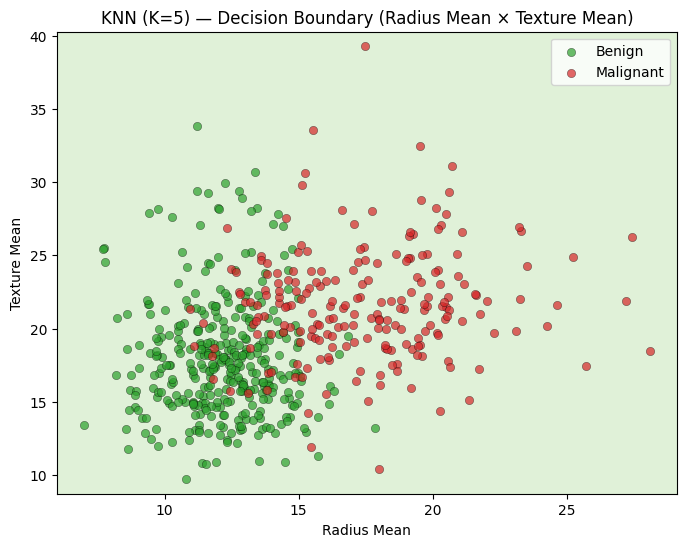

In [8]:
# Build best model
knn_best = KNN(k=best_k)
knn_best.fit(X_train, y_train)

# Grid over feature 0 (radius mean) and feature 1 (texture mean)
# Fix all other features at their training-set mean
x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx0, xx1 = np.meshgrid(
    np.linspace(x0_min, x0_max, 200),
    np.linspace(x1_min, x1_max, 200),
)

# Build full 30-feature grid: fix features 2..29 at training mean
feature_means = X_train.mean(axis=0)
grid_base = np.tile(feature_means, (xx0.ravel().shape[0], 1))
grid_base[:, 0] = xx0.ravel()
grid_base[:, 1] = xx1.ravel()

Z = knn_best.predict(grid_base)
Z_numeric = np.where(Z == "B", 1, 0).reshape(xx0.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx0, xx1, Z_numeric, alpha=0.25, cmap="RdYlGn", levels=[-0.5, 0.5, 1.5])
plt.scatter(X[y == "B", 0], X[y == "B", 1], color="tab:green", alpha=0.7, label="Benign",    edgecolors="k", linewidths=0.3)
plt.scatter(X[y == "M", 0], X[y == "M", 1], color="tab:red",   alpha=0.7, label="Malignant", edgecolors="k", linewidths=0.3)
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title(f"KNN (K={best_k}) — Decision Boundary (Radius Mean × Texture Mean)")
plt.legend()
plt.show()